# Overview

Every dataset {mod}`mantispy.ds` serves, with how many wells, features and controls it has, and how many cells a
well holds.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mantispy as mt

In [2]:
WELLS = [
    "bbbc021",
    "rohban",
    "pki",
    "jump_target2",
    "jump_crispr",
    "luad",
    "agnp",
    "neuropainting",
    "amish",
    "chroma",
    "oasis_pilot",
    "miami",
]
# jump_target2 loads two of its twelve plates unless asked for all of them.
datasets = {name: getattr(mt.ds, name)(**({"plates": None} if name == "jump_target2" else {})) for name in WELLS}

rows = []
for name, adata in datasets.items():
    obs = adata.obs
    rows.append(
        {
            "dataset": name,
            "accession": adata.uns["mantispy"]["dataset"],
            "wells": adata.n_obs,
            "features": adata.n_vars,
            "plates": obs["Metadata_Plate"].nunique(),
            "controls": int(obs["Metadata_Control"].sum()) if "Metadata_Control" in obs else pd.NA,
            "cells per well": obs["Metadata_CellCount"].median(),
            "fields per well": obs["Metadata_SiteCount"].median() if "Metadata_SiteCount" in obs else pd.NA,
        }
    )
pd.DataFrame(rows).set_index("dataset")

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/2OnMUz3_/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,accession,wells,features,plates,controls,cells per well,fields per well
dataset,,,,,,,
bbbc021,BBBC021,632,473,55,330,592.0,4.0
rohban,cpg0017-rohban-pathways,1918,3634,5,120,633.0,9.0
pki,cpg0008-pki,3072,5857,8,832,1669.0,9.0
jump_target2,cpg0016-jump,4608,3634,12,769,1397.0,9.0
jump_crispr,cpg0016-jump-assembled,51185,597,148,<NA>,3093.0,<NA>
luad,cpg0031-caicedo-cmvip,6144,432,16,<NA>,1757.5,9.0
agnp,cpg0040-garcia-fossa-AgNP,180,112,4,<NA>,317.5,28.5
neuropainting,cpg0038-tegtmeyer-neuropainting,1691,204,4,<NA>,92.0,4.0
amish,cpg0047-amish,468,575,3,<NA>,373.0,9.0


`controls` is `Metadata_Control`, which only the loaders that know a screen's negative control set.
Three datasets are not wells and are left out of the table:

- `pooled_rare` holds one profile per barcode of a pooled screen, so there is no well to count cells in;
- `jump_cells` holds 13,578 single cells of one JUMP plate, see [its page](jump_cells.ipynb);
- `jump_plate` holds the images and segmentations of one well of the same plate.

## Where the cell counts come from

`Metadata_CellCount` is the number of cells behind a row, and `Metadata_SiteCount` the number of fields of view
that contributed them.
Every count is exact, taken from what the upstream pipeline measured:

| dataset | cell count |
| --- | --- |
| bbbc021 | summed from the `Image.csv` of each well, see [its page](bbbc021.ipynb) |
| rohban, pki | `Metadata_Count_Cells` in the augmented profiles |
| luad, miami, oasis_pilot, amish, chroma, neuropainting | `Metadata_Count_Cells` in the profiles |
| agnp | `Metadata_Object_Count` in the profiles |
| jump_target2 | each plate's backend table, see [its page](jump_target2.ipynb) |
| jump_crispr | `crispr_cell_counts.csv.gz` of [jump-profiling-recipe](https://github.com/broadinstitute/jump-profiling-recipe), the counts its cell-count correction regresses out |

`Metadata_Object_Count` is the number of cells pycytominer aggregated into a well.
It equals `Metadata_Count_Cells` in every well of the 58 plates here that publish both, so agnp's count is as exact as the others.
{func}`~mantispy.io.read_profiles` copies either one to `Metadata_CellCount`, and `Metadata_Site_Count` to `Metadata_SiteCount`, so a Gallery file read directly carries them too.

## Cells per field

Datasets image different numbers of fields per well, and so do plates within some of them.
Cells per field compares them on one scale.

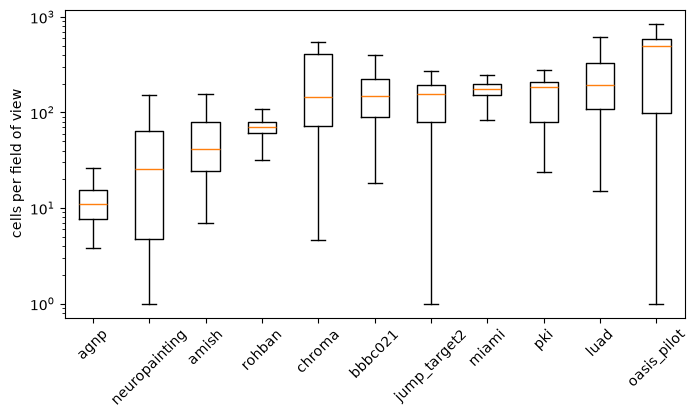

In [3]:
per_field = {
    name: (adata.obs["Metadata_CellCount"] / adata.obs["Metadata_SiteCount"]).dropna().to_numpy()
    for name, adata in datasets.items()
    if "Metadata_SiteCount" in adata.obs
}
order = sorted(per_field, key=lambda name: np.median(per_field[name]))
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([per_field[name] for name in order], tick_labels=order, showfliers=False)
ax.set_yscale("log")
ax.set_ylabel("cells per field of view")
ax.tick_params(axis="x", rotation=45)

`Metadata_SiteCount` counts the fields that contributed cells, which need not be all those imaged: an empty field
contributes none, and so does one left out of the analysis.
[JUMP-Target-2](jump_target2.ipynb) has examples of both.
jump_crispr has no field count, because the recipe's table publishes none.